In [58]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

In [60]:
data = pd.read_csv("SocialNetworkAds.csv")
data.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [62]:
X = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

In [66]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [68]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [70]:
y_pred = model.predict(X_test)

In [72]:
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

In [74]:
accuracy = (TP + TN) / (TP + TN + FP + FN)
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall = TP / (TP + FN)

In [76]:
print("Confusion Matrix:\n", cm)
print("True Positive:", TP)
print("False Positive:", FP)
print("True Negative:", TN)
print("False Negative:", FN)
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

Confusion Matrix:
 [[61  2]
 [12 25]]
True Positive: 25
False Positive: 2
True Negative: 61
False Negative: 12
Accuracy: 0.86
Error Rate: 0.14
Precision: 0.9259259259259259
Recall: 0.6756756756756757


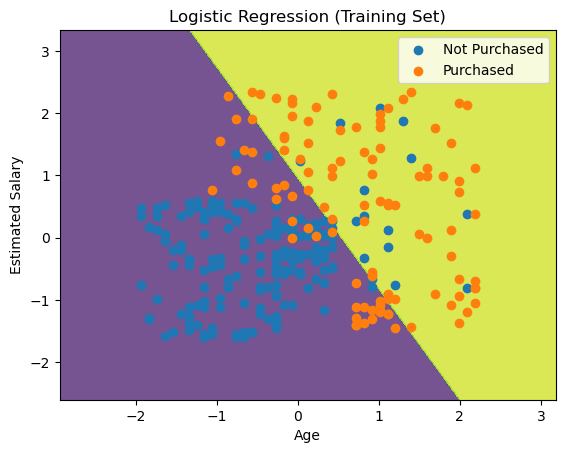

In [78]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

X_set, y_set = X_train, y_train

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75
)

plt.scatter(
    X_set[y_set == 0, 0],
    X_set[y_set == 0, 1],
    label='Not Purchased'
)

plt.scatter(
    X_set[y_set == 1, 0],
    X_set[y_set == 1, 1],
    label='Purchased'
)

plt.title('Logistic Regression (Training Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

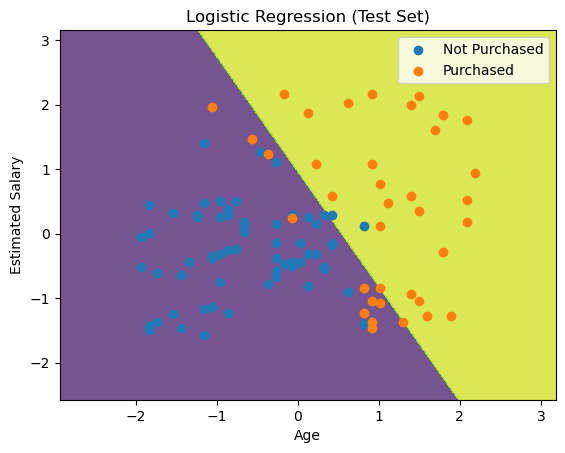

In [82]:
X_set, y_set = X_test, y_test

X1, X2 = np.meshgrid(
    np.arange(X_set[:, 0].min() - 1, X_set[:, 0].max() + 1, 0.01),
    np.arange(X_set[:, 1].min() - 1, X_set[:, 1].max() + 1, 0.01)
)

plt.contourf(
    X1, X2,
    model.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75
)

plt.scatter(
    X_set[y_set == 0, 0],
    X_set[y_set == 0, 1],
    label='Not Purchased'
)

plt.scatter(
    X_set[y_set == 1, 0],
    X_set[y_set == 1, 1],
    label='Purchased'
)

plt.title('Logistic Regression (Test Set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()